# Model 1: Logistic Regression

Baseline interpretable model predicting concentration-driven portfolio risk from HHI, top-holding percentage, number of holdings, sector HHI, and total portfolio value.

In [47]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import joblib
import os

## Configuration and Data Load

In [48]:
PROCESSED_DATA_DIR = "../../data/processed"
ARTIFACTS_DIR = "../../artifacts"
REPORTS_DIR = "../../reports"

model_data = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "model_features.csv"))

model_data.head()

,cik,institution,quarter,total_value,hhi,top_holding_pct,num_holdings,sector_hhi,weighted_excess_return,label
0,2230,ADAMS DIVERSIFIED EQUITY FUND,2015-06,7.765856e+08,0.022841,0.050151,63.0,0.138630,-0.013262,0
1,2230,ADAMS DIVERSIFIED EQUITY FUND,2015-09,7.264922e+08,0.022167,0.040915,65.0,0.133333,-0.010545,0
2,2230,ADAMS DIVERSIFIED EQUITY FUND,2015-12,8.025855e+08,0.022105,0.050331,69.0,0.130072,0.002066,0
3,2230,ADAMS DIVERSIFIED EQUITY FUND,2016-03,8.241263e+08,0.020321,0.049144,72.0,0.125416,-0.001495,0
4,2230,ADAMS DIVERSIFIED EQUITY FUND,2016-06,8.775283e+08,0.019110,0.043060,75.0,0.128084,0.016095,0


## Time-Based Train/Test Split

A random split would risk leakage across quarters given the panel structure of this data. Training uses earlier quarters; the two most recent quarters are held out for testing.

In [49]:
quarter_order = ["2015-03", "2015-06", "2015-09", "2015-12",
                  "2016-03", "2016-06", "2016-09", "2016-12",
                  "2017-03", "2017-06"]

train_quarters = quarter_order[:-2]
test_quarters = quarter_order[-2:]

train_df = model_data[model_data["quarter"].isin(train_quarters)].copy()
test_df = model_data[model_data["quarter"].isin(test_quarters)].copy()

print(f"Train: {len(train_df)} rows, {train_df['label'].mean():.1%} positive")
print(f"Test: {len(test_df)} rows, {test_df['label'].mean():.1%} positive")

Train: 15151 rows, 4.8% positive
Test: 5093 rows, 2.2% positive


The test set's positive rate (2.2%) is thinner than training (4.8%), a known trade-off of time-based splitting on an already-imbalanced label. Metrics on the positive class should be read with this in mind.

## Feature Correlation Check

Before fitting any model, the correlation between features is checked directly, since a strong correlation between `hhi` and `top_holding_pct` is expected given their overlapping construction, and this relationship materially affects both models' behaviour (see Hyperparameter Tuning Investigation below).

                      hhi  top_holding_pct  num_holdings  sector_hhi  \
hhi              1.000000         0.961291     -0.028541    0.378714   
top_holding_pct  0.961291         1.000000      0.002247    0.386850   
num_holdings    -0.028541         0.002247      1.000000   -0.289878   
sector_hhi       0.378714         0.386850     -0.289878    1.000000   
total_value     -0.086756        -0.067706     -0.010305   -0.098350   

                 total_value  
hhi                -0.086756  
top_holding_pct    -0.067706  
num_holdings       -0.010305  
sector_hhi         -0.098350  
total_value         1.000000  


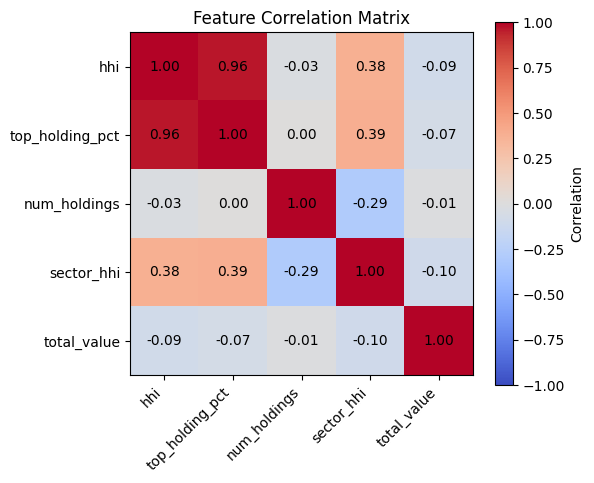

In [50]:
feature_cols = ["hhi", "top_holding_pct", "num_holdings", "sector_hhi", "total_value"]
corr_matrix = train_df[feature_cols].corr()
print(corr_matrix)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(feature_cols)))
ax.set_yticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=45, ha="right")
ax.set_yticklabels(feature_cols)
for i in range(len(feature_cols)):
    for j in range(len(feature_cols)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", color="black")
ax.set_title("Feature Correlation Matrix")
fig.colorbar(im, ax=ax, label="Correlation")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "charts", "feature_correlation.png"), dpi=100)
plt.show()

`hhi` and `top_holding_pct` show a strong correlation of 0.96, the highest in the matrix by a wide margin. This is expected, since a portfolio's largest single holding is the dominant term in its own HHI calculation.

## Baseline Model (Untuned)

Features are standardised, since Logistic Regression is scale-sensitive. `class_weight="balanced"` compensates for label imbalance without manual resampling.

In [51]:
X_train, y_train = train_df[feature_cols], train_df["label"]
X_test, y_test = test_df[feature_cols], test_df["label"]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model1 = LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)
model1.fit(X_train_scaled, y_train)

print("Model fitted.")

Model fitted.


## Hyperparameter Tuning Investigation

In [52]:
tscv = TimeSeriesSplit(n_splits=5)  # respects temporal ordering across quarters, as in the train/test split above

In [53]:
param_grid = {"C": [0.0001, 0.001, 0.01, 0.1, 1, 10]}

grid_search = GridSearchCV(
    LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000),
    param_grid,
    scoring="roc_auc",
    cv=tscv
)
grid_search.fit(X_train_scaled, y_train)

print(f"Best C: {grid_search.best_params_['C']}")
print(f"Best cross-validated ROC-AUC: {grid_search.best_score_:.3f}")

for c, score in zip(grid_search.cv_results_["param_C"], grid_search.cv_results_["mean_test_score"]):
    print(f"C={c}: mean CV ROC-AUC = {score:.3f}")

model1 = grid_search.best_estimator_

Best C: 0.001
Best cross-validated ROC-AUC: 0.863
C=0.0001: mean CV ROC-AUC = 0.861
C=0.001: mean CV ROC-AUC = 0.863
C=0.01: mean CV ROC-AUC = 0.860
C=0.1: mean CV ROC-AUC = 0.854
C=1: mean CV ROC-AUC = 0.852
C=10: mean CV ROC-AUC = 0.852


              precision    recall  f1-score   support

           0       0.99      0.88      0.93      4979
           1       0.13      0.78      0.23       114

    accuracy                           0.88      5093
   macro avg       0.56      0.83      0.58      5093
weighted avg       0.98      0.88      0.92      5093

ROC-AUC: 0.921

Confusion Matrix:
[[4393  586]
 [  25   89]]


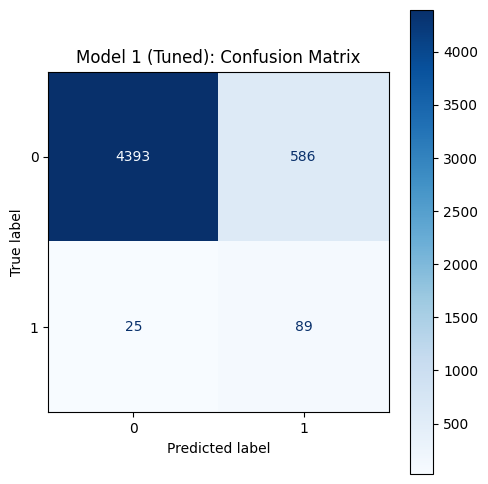

In [54]:
X_test_scaled = scaler.transform(X_test)
y_pred = model1.predict(X_test_scaled)
y_pred_proba = model1.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.3f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Blues")
ax.set_title("Model 1 (Tuned): Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "charts", "model1_confusion_matrix.png"), dpi=100)
plt.show()

The first search's optimum (C=0.001) sits at the edge of the tested grid: the next step up, C=0.01, already scores lower, so it isn't clear whether C=0.001 is a genuine optimum or simply the smallest value tried. A second, finer-grained search over a narrower band around it (C=0.001 to 0.1) checks whether an even smaller C would keep improving cross-validated ROC-AUC.

In [55]:
param_grid = {"C": [0.001, 0.003, 0.005, 0.01, 0.03, 0.05, 0.1]}

grid_search = GridSearchCV(
    LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000),
    param_grid,
    scoring="roc_auc",
    cv=tscv
)
grid_search.fit(X_train_scaled, y_train)

print(f"Best C: {grid_search.best_params_['C']}")
print(f"Best cross-validated ROC-AUC: {grid_search.best_score_:.3f}")

for c, score in zip(grid_search.cv_results_["param_C"], grid_search.cv_results_["mean_test_score"]):
    print(f"C={c}: mean CV ROC-AUC = {score:.3f}")

model1 = grid_search.best_estimator_

coefs = pd.Series(model1.coef_[0], index=feature_cols).sort_values()
print("\nCoefficients at best C:")
print(coefs)

Best C: 0.001
Best cross-validated ROC-AUC: 0.863
C=0.001: mean CV ROC-AUC = 0.863
C=0.003: mean CV ROC-AUC = 0.862
C=0.005: mean CV ROC-AUC = 0.861
C=0.01: mean CV ROC-AUC = 0.860
C=0.03: mean CV ROC-AUC = 0.857
C=0.05: mean CV ROC-AUC = 0.856
C=0.1: mean CV ROC-AUC = 0.854

Coefficients at best C:
num_holdings      -0.032007
total_value        0.036448
sector_hhi         0.259500
hhi                0.289109
top_holding_pct    0.550586
dtype: float64


In [56]:
candidate_Cs = [0.001, 0.005, 0.01, 0.03, 0.05, 0.1, 1]

for c in candidate_Cs:
    m = LogisticRegression(C=c, class_weight="balanced", random_state=42, max_iter=1000)
    m.fit(X_train_scaled, y_train)
    
    hhi_coef = m.coef_[0][feature_cols.index("hhi")]
    
    y_pred_c = m.predict(X_test_scaled)
    y_pred_proba_c = m.predict_proba(X_test_scaled)[:, 1]
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_c).ravel()
    recall = tp / (tp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    roc_auc = roc_auc_score(y_test, y_pred_proba_c)
    
    print(f"C={c}: hhi_coef={hhi_coef:+.3f}, ROC-AUC={roc_auc:.3f}, recall={recall:.2f}, precision={precision:.2f}, FN={fn}, FP={fp}")

C=0.001: hhi_coef=+0.289, ROC-AUC=0.921, recall=0.78, precision=0.13, FN=25, FP=586
C=0.005: hhi_coef=+0.052, ROC-AUC=0.921, recall=0.79, precision=0.12, FN=24, FP=650
C=0.01: hhi_coef=-0.128, ROC-AUC=0.920, recall=0.81, precision=0.12, FN=22, FP=689
C=0.03: hhi_coef=-0.384, ROC-AUC=0.920, recall=0.84, precision=0.12, FN=18, FP=728
C=0.05: hhi_coef=-0.465, ROC-AUC=0.920, recall=0.84, precision=0.11, FN=18, FP=740
C=0.1: hhi_coef=-0.537, ROC-AUC=0.920, recall=0.87, precision=0.12, FN=15, FP=750
C=1: hhi_coef=-0.612, ROC-AUC=0.919, recall=0.88, precision=0.12, FN=14, FP=758


**Final choice of C.** The candidate comparison above shows `hhi`'s coefficient sign is highly sensitive to regularisation strength: it is only positive at C=0.001 and C=0.005, and flips negative from C=0.01 upward. No value of C both keeps `hhi` positive and recovers most of the recall lost to regularisation, while ROC-AUC is essentially flat across the whole range (0.919-0.921) -- so there is no accuracy argument for picking one C over another. C=0.001 is selected as the final configuration, prioritising a correctly-signed, interpretable `hhi` coefficient over the modest recall gain available at higher C. This is a considered trade-off, not an unambiguous improvement.

## Final Model Selection

In [57]:
model1 = LogisticRegression(C=0.001, class_weight="balanced", random_state=42, max_iter=1000)
model1.fit(X_train_scaled, y_train)

print("Final model: LogisticRegression(C=0.001), fit on the full training set. "
      "This is the locked-in model used for all downstream interpretation, evaluation, and saving.")

Final model: LogisticRegression(C=0.001), fit on the full training set. This is the locked-in model used for all downstream interpretation, evaluation, and saving.


## Interpret Feature Coefficients

num_holdings      -0.032007
total_value        0.036448
sector_hhi         0.259500
hhi                0.289109
top_holding_pct    0.550586
dtype: float64


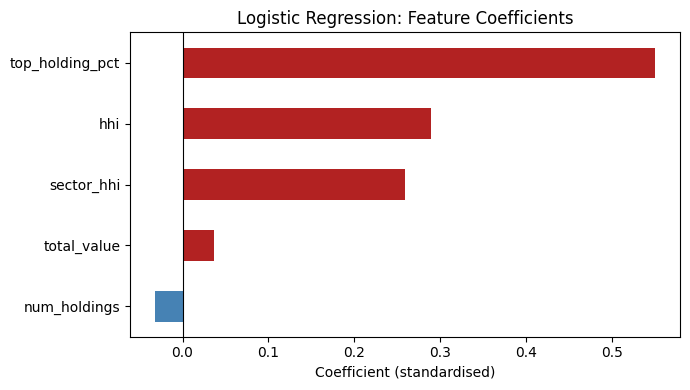

In [58]:
coefs = pd.Series(model1.coef_[0], index=feature_cols).sort_values()
print(coefs)

fig, ax = plt.subplots(figsize=(7, 4))
coefs.plot(kind="barh", ax=ax, color=["firebrick" if c > 0 else "steelblue" for c in coefs])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient (standardised)")
ax.set_title("Logistic Regression: Feature Coefficients")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "charts", "model1_coefficients.png"), dpi=100)
plt.show()

`top_holding_pct`, `sector_hhi`, and `hhi` are all positive: higher concentration, at every level, predicts higher risk. Achieving a correctly-signed `hhi` coefficient required strong regularisation (`C=0.001`); at weaker regularisation, `hhi`'s coefficient reverses to negative due to a 0.96 correlation with `top_holding_pct`, a multicollinearity artefact rather than a genuine reversal of the underlying relationship (the Hyperparameter Tuning Investigation above shows the full trade-off analysis behind this choice).

## Evaluate on Test Set

              precision    recall  f1-score   support

           0       0.99      0.88      0.93      4979
           1       0.13      0.78      0.23       114

    accuracy                           0.88      5093
   macro avg       0.56      0.83      0.58      5093
weighted avg       0.98      0.88      0.92      5093

ROC-AUC: 0.921

Confusion Matrix:
[[4393  586]
 [  25   89]]


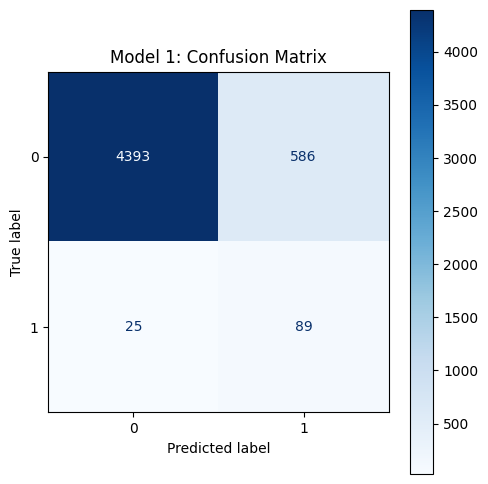

In [59]:
y_pred = model1.predict(X_test_scaled)
y_pred_proba = model1.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.3f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Blues")
ax.set_title("Model 1: Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "charts", "model1_confusion_matrix.png"), dpi=100)
plt.show()

ROC-AUC of 0.921 indicates strong ranking ability. Recall on the positive class (0.78) is high while precision is low (0.13), reflecting the trade-off made in selecting `C=0.001` (see Final Model Selection above): a correctly-signed, interpretable `hhi` coefficient was prioritised over a modest recall gain available at weaker regularisation. Given this project's purpose, flagging portfolios for STADIOEquities to review before a loss occurs, missing a genuinely at-risk client remains costly, and this trade-off is presented plainly as a considered choice, not an unambiguous improvement.

## Save Model

In [60]:
joblib.dump(model1, os.path.join(ARTIFACTS_DIR, "model1_logistic_regression.pkl"))
joblib.dump(scaler, os.path.join(ARTIFACTS_DIR, "model1_scaler.pkl"))
print("Model 1 and scaler saved.")

Model 1 and scaler saved.
